# Computational Intelligence Project: Island Genetic Algorithm


## The Problem
We need to collect gold from $N$ cities and return it to a base (0). 
**Cost Function**: $c(d, w) = d + (\alpha \cdot d \cdot w)^\beta$

Where $\beta$ can be high (e.g., 5.0), making heavy loads extremely expensive over distance.

In [1]:
import logging
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations

logging.basicConfig(level=logging.INFO, format='%(message)s')

## 1. Problem Definition
We use the provided `Problem` class to generate the graph and calculate costs.

In [2]:
class Problem:
    def __init__(self, num_cities: int, *, alpha: float = 1.0, beta: float = 1.0, density: float = 0.5, seed: int = 42):
        rng = np.random.default_rng(seed)
        self._alpha = alpha
        self._beta = beta
        cities = rng.random(size=(num_cities, 2))
        cities[0, 0] = cities[0, 1] = 0.5

        self._graph = nx.Graph()
        self._graph.add_node(0, pos=(cities[0, 0], cities[0, 1]), gold=0)
        for c in range(1, num_cities):
            self._graph.add_node(c, pos=(cities[c, 0], cities[c, 1]), gold=(1 + 999 * rng.random()))

        tmp = cities[:, np.newaxis, :] - cities[np.newaxis, :, :]
        d = np.sqrt(np.sum(np.square(tmp), axis=-1))
        for c1, c2 in combinations(range(num_cities), 2):
            if rng.random() < density or c2 == c1 + 1:
                self._graph.add_edge(c1, c2, dist=d[c1, c2])
        assert nx.is_connected(self._graph)

    @property
    def graph(self) -> nx.Graph:
        return nx.Graph(self._graph)

    @property
    def alpha(self):
        return self._alpha

    @property
    def beta(self):
        return self._beta

    def cost(self, path, weight):
        dist = nx.path_weight(self._graph, path, weight='dist')
        return dist + (self._alpha * dist * weight) ** self._beta

    def baseline(self):
        cost = 0
        for dest, path in nx.single_source_dijkstra_path(
            self._graph, source=0, weight='weight'
        ).items():
            if dest == 0:
                continue
            cost += self.cost(path, 0) + self.cost(path, self._graph.nodes[dest]['gold'])
        return cost

    def plot(self):
        plt.figure(figsize=(10, 10))
        pos = nx.get_node_attributes(self._graph, 'pos')
        size = [100] + [self._graph.nodes[n]['gold'] for n in range(1, len(self._graph))]
        color = ['red'] + ['lightblue'] * (len(self._graph) - 1)
        nx.draw(self._graph, pos, with_labels=True, node_color=color, node_size=size)

## 2. Virtual Nodes Strategy
Since cost scales exponentially with weight, carrying a full city's gold (e.g., 800kg) is often suboptimal. 
We split heavy cities into smaller "Virtual Nodes" to allow partial pickups.

In [3]:
def create_virtual_cities(problem, scale=0.8):
    num_cities_real = problem.graph.number_of_nodes()
    real_golds = nx.get_node_attributes(problem.graph, 'gold')
    
    # Calculate adaptive parameters based on problem instance
    dists = dict(nx.all_pairs_dijkstra_path_length(problem.graph, weight='dist'))
    all_dists = [d for u in dists for d in dists[u].values() if d > 0]
    avg_dist = np.mean(all_dists) if all_dists else 1.0
    
    # Sensitivity factor
    S = (problem.alpha ** problem.beta) * problem.beta * (avg_dist ** problem.beta) if problem.beta > 0 else 1.0
    
    # Density approximation
    n = num_cities_real
    m = problem.graph.number_of_edges()
    density = m / (n * (n - 1) / 2) if n > 1 else 1.0
    density_factor = 1.0 / max(density, 0.1)
    city_factor = np.log(n + 1)
    
    # Base Chunk Size
    C = 1000.0
    denom = S * density_factor * city_factor
    chunk_base = C / denom if denom > 1e-6 else C
    chunk_base = np.clip(chunk_base, 20.0, 300.0)
    
    target_chunk = chunk_base * scale
    
    # Generation
    virtual_cities = []
    virtual_map = {}
    node_golds = {}
    vid_counter = 1
    
    for c in range(1, num_cities_real):
        gold = real_golds[c]
        if gold > 1.2 * target_chunk and problem.beta > 1.0:
            num_chunks = int(np.ceil(gold / target_chunk))
            gold_per_chunk = gold / num_chunks
            for _ in range(num_chunks):
                virtual_cities.append(vid_counter)
                virtual_map[vid_counter] = c
                node_golds[vid_counter] = gold_per_chunk
                vid_counter += 1
        else:
            virtual_cities.append(vid_counter)
            virtual_map[vid_counter] = c
            node_golds[vid_counter] = gold
            vid_counter += 1
            
    return virtual_cities, virtual_map, node_golds, dists, int(200.0 / (problem.beta * density_factor))

### 3. Optimal Split (Route-First, Cluster-Second)
As cost increases non-linearly with $ \beta \ge 1 $ we definitely need to return to base multiple times. Given a permutation of virtual nodes, we need to find the optimal places to return to base.

We use a Dynamic Programming approach with a **sliding window**.

In [4]:
def split_permutation(permutation, problem, dists, node_golds, virtual_map, win_base, win_scale):
    n = len(permutation)
    win = int(win_base * win_scale)
    win = max(5, win)
    
    V = [float('inf')] * (n + 1)
    V[0] = 0.0
    P = [-1] * (n + 1)
    
    def get_dist(u, v):
        u_r = 0 if u == 0 else virtual_map[u]
        v_r = 0 if v == 0 else virtual_map[v]
        return dists[u_r][v_r]
    
    for i in range(n):
        if V[i] == float('inf'): continue
        
        current_load = 0.0
        # 0 -> u
        u = permutation[i]
        d0 = get_dist(0, u)
        forward_cost = d0
        
        prev = u
        current_load += node_golds[prev]
        
        # Return i->0
        dr = get_dist(prev, 0)
        trip_cost = forward_cost + dr + (problem.alpha * dr * current_load) ** problem.beta
        
        if V[i] + trip_cost < V[i+1]:
            V[i+1] = V[i] + trip_cost
            P[i+1] = i
            
        # Window check
        limit = min(i + win + 1, n + 1)
        for j in range(i + 2, limit):
            new_city = permutation[j-1]
            d_seg = get_dist(prev, new_city)
            forward_cost += d_seg + (problem.alpha * d_seg * current_load) ** problem.beta
            
            current_load += node_golds[new_city]
            prev = new_city
            
            dr = get_dist(new_city, 0)
            total = forward_cost + dr + (problem.alpha * dr * current_load) ** problem.beta
            
            if V[i] + total < V[j]:
                V[j] = V[i] + total
                P[j] = i
                
    trips = []
    curr = n
    while curr > 0:
        start = P[curr]
        trips.append(permutation[start:curr])
        curr = start
    trips.reverse()
    return V[n], trips

## 4. Island Genetic Algorithm 
We implement the `Individual` and `Island` classes.
The **Individual** holds the genome (route) and self-adaptive parameters.
The **Island** manages a sub-population with specific priors (Exploit, Explore, etc.).

We can do a smart initialization for a few individuals in our islands. There are different meta-heuristics here that could be discussed. We know one thing for sure: **Carrying a heavy load over a long distance is the worst possible thing a thief can do**. So our initialization strategy focuses to mitigate this: 
1. **Start Empty**: When you leave the base (0), you have 0 weight. Travel is cheap. You should use this cheap travel to go as far as possible.
2. **Collect Far Away**: Pick up gold from the farthest cities first.
3. **Return Heavy**: As you collect gold, your weight increases. You want your return trip to be as short as possible to minimize the loaded penalty.

In [ ]:
ISLAND_PRIORS = {
    'Exploit': {'mut_rate': (0.05, 0.15), 'win_scale': (1.0, 1.5), 'mut_mix': [0.1, 0.1, 0.8]},
    'Balanced': {'mut_rate': (0.15, 0.35), 'win_scale': (0.8, 1.2), 'mut_mix': [0.3, 0.3, 0.4]},
    'Explore': {'mut_rate': (0.35, 0.60), 'win_scale': (0.6, 1.0), 'mut_mix': [0.4, 0.4, 0.2]},
    'Chaos': {'mut_rate': (0.60, 0.90), 'win_scale': (0.3, 0.7), 'mut_mix': [0.33, 0.33, 0.33]}
}

class Individual:
    def __init__(self, genome, params):
        self.genome = genome
        self.params = params
        self.cost = float('inf')
        self.trips = []

class Island:
    def __init__(self, role, pop_size, problem_data):
        self.role = role
        self.pop_size = pop_size
        self.data = problem_data # (problem, dists, golds, map, win_base)
        self.priors = ISLAND_PRIORS[role]
        self.population = []
        
    def initialize(self, cities):
        self.population = []
        
        problem, dists, _, v_map, _ = self.data
        
        # Look up how far each city (or the virtual node that corresponds to it) is from Base.
        def get_d(u): 
            return dists[v_map[u]][0] # Dist to 0
            
        # Sort all cities (farthest first)
        sorted_perm = sorted(cities, key=get_d, reverse=True)
        
        # Inject this specific "perfect" order into the population
        for _ in range(max(1, int(self.pop_size * 0.1))):
            self.population.append(Individual(list(sorted_perm), self._sample_params()))
            
        while len(self.population) < self.pop_size:
            perm = list(cities)
            np.random.shuffle(perm)
            self.population.append(Individual(perm, self._sample_params()))
            
        self.evaluate_pop()

    def _sample_params(self):
        return {
            'mut_rate': np.random.uniform(*self.priors['mut_rate']),
            'win_scale': np.random.uniform(*self.priors['win_scale']),
            'mut_mix': list(self.priors['mut_mix'])
        }
        
    def evaluate_pop(self):
        problem, dists, golds, v_map, win_base = self.data
        for ind in self.population:
            if ind.cost == float('inf'):
                ind.cost, ind.trips = split_permutation(ind.genome, problem, dists, golds, v_map, win_base, ind.params['win_scale'])
        self.population.sort(key=lambda x: x.cost)

    def evolve(self):
        # Elitism
        new_pop = self.population[:2]
        
        while len(new_pop) < self.pop_size:
            # Tournament
            p1 = min(np.random.choice(self.population, 3), key=lambda x: x.cost)
            p2 = min(np.random.choice(self.population, 3), key=lambda x: x.cost)
            
            # OX1 Crossover
            size = len(p1.genome)
            a, b = sorted(np.random.choice(range(size), 2, replace=False))
            child_g = [None] * size
            child_g[a:b+1] = p1.genome[a:b+1]
            curr, p2_idx = (b+1)%size, (b+1)%size
            while None in child_g:
                if p2.genome[p2_idx] not in child_g[a:b+1]:
                    child_g[curr] = p2.genome[p2_idx]
                    curr = (curr + 1) % size
                p2_idx = (p2_idx + 1) % size
                
            # Param Crossover
            alpha = np.random.random()
            child_p = {}
            for k in ['mut_rate', 'win_scale']:
                child_p[k] = alpha * p1.params[k] + (1-alpha) * p2.params[k]
            
            mix = alpha * np.array(p1.params['mut_mix']) + (1-alpha) * np.array(p2.params['mut_mix'])
            child_p['mut_mix'] = list(mix / mix.sum())
            
            # Mutation
            # 1. Params
            tau = 0.1
            child_p['mut_rate'] = np.clip(child_p['mut_rate'] * np.exp(tau * np.random.normal()), 0.05, 0.95)
            child_p['win_scale'] = np.clip(child_p['win_scale'] * np.exp(tau * np.random.normal()), 0.3, 2.0)
            mix = np.abs(np.array(child_p['mut_mix']) + np.random.normal(0, 0.1, 3))
            child_p['mut_mix'] = list(mix / mix.sum())
            
            # 2. Genome
            if np.random.random() < child_p['mut_rate']:
                op = np.random.choice(['swap', 'inv', 'scramble'], p=child_p['mut_mix'])
                if op == 'swap':
                    i, j = np.random.choice(range(size), 2, replace=False)
                    child_g[i], child_g[j] = child_g[j], child_g[i]
                elif op == 'inv':
                    i, j = sorted(np.random.choice(range(size), 2, replace=False))
                    child_g[i:j+1] = child_g[i:j+1][::-1]
                elif op == 'scramble':
                    i, j = sorted(np.random.choice(range(size), 2, replace=False))
                    sub = child_g[i:j+1]
                    np.random.shuffle(sub)
                    child_g[i:j+1] = sub
                    
            new_pop.append(Individual(child_g, child_p))
            
        self.population = new_pop
        self.evaluate_pop()

## 5. Main Solver Loop
We tie everything together, managing migration between islands.

- Update (16 Dec): Now recording history

In [23]:
def solve_problem(num_cities=30, alpha=1.0, beta=1.0, seed=42):
    p = Problem(num_cities, alpha=alpha, beta=beta, seed=seed)
    
    # 1. Virtual Nodes
    v_cities, v_map, golds, dists, win_base = create_virtual_cities(p)
    problem_data = (p, dists, golds, v_map, win_base)
    
    # 2. Init Islands
    islands = []
    for role in ['Exploit', 'Balanced', 'Explore', 'Chaos']:
        isl = Island(role, 30, problem_data)
        isl.initialize(v_cities)
        islands.append(isl)
        
    global_best = islands[0].population[0]
    
    generations = 120
    
    print(f"Initial Best Cost: {global_best.cost:.2e}")

    history = {
        'gen': [],
        'global_best': [],
        'islands': {role: {'best_cost': [], 'avg_mut_rate': [], 'avg_win_scale': []} for role in {'Exploit', 'Balanced', 'Explore', 'Chaos'}}
    }
    
    for g in range(generations):
        
        history['gen'].append(g)
        history['global_best'].append(global_best.cost)
        
        for isl in islands:
            isl.evolve()
            best_isl = isl.population[0]
            if best_isl.cost < global_best.cost:
                global_best = best_isl
                print(f"Gen {g} [{isl.role}]: New Best {global_best.cost:.2e}")
            
            history['islands'][isl.role]['best_cost'].append(best_isl.cost)
            history['islands'][isl.role]['avg_mut_rate'].append(isl.population[0].params['mut_rate'])
            history['islands'][isl.role]['avg_win_scale'].append(isl.population[0].params['win_scale'])
        
        # Migration (Ring)
        if g % 20 == 0 and g > 0:
            migrants = [isl.population[0] for isl in islands]
            for i in range(4):
                target = islands[(i+1)%4]
                # Clone and inject
                m = migrants[i]
                clone = Individual(list(m.genome), m.params.copy())
                target.population[-1] = clone # replace worst
                target.evaluate_pop()
                
    return global_best, p, v_map, history

In [24]:
# Run the solver with logging
best_ind, problem, v_map, history = solve_problem(num_cities=150, alpha=0.8, beta=4.5)

Initial Best Cost: 1.11e+11
Gen 0 [Balanced]: New Best 1.11e+11
Gen 0 [Explore]: New Best 1.11e+11
Gen 1 [Exploit]: New Best 1.11e+11
Gen 1 [Balanced]: New Best 1.10e+11
Gen 2 [Balanced]: New Best 1.09e+11
Gen 2 [Explore]: New Best 1.09e+11
Gen 2 [Chaos]: New Best 1.08e+11
Gen 3 [Chaos]: New Best 1.07e+11
Gen 4 [Chaos]: New Best 1.05e+11
Gen 5 [Chaos]: New Best 1.05e+11
Gen 8 [Chaos]: New Best 1.04e+11
Gen 10 [Chaos]: New Best 1.04e+11
Gen 11 [Chaos]: New Best 1.04e+11
Gen 14 [Chaos]: New Best 1.03e+11
Gen 15 [Chaos]: New Best 1.03e+11
Gen 16 [Chaos]: New Best 1.03e+11
Gen 17 [Chaos]: New Best 1.03e+11
Gen 18 [Chaos]: New Best 1.02e+11
Gen 20 [Chaos]: New Best 1.02e+11
Gen 21 [Exploit]: New Best 1.02e+11
Gen 22 [Exploit]: New Best 1.02e+11
Gen 23 [Exploit]: New Best 1.02e+11
Gen 24 [Exploit]: New Best 1.01e+11
Gen 24 [Chaos]: New Best 1.01e+11
Gen 25 [Balanced]: New Best 1.01e+11
Gen 27 [Balanced]: New Best 1.01e+11
Gen 28 [Balanced]: New Best 1.00e+11
Gen 30 [Balanced]: New Best 1.00e


Final Solution Cost: 9.09e+10


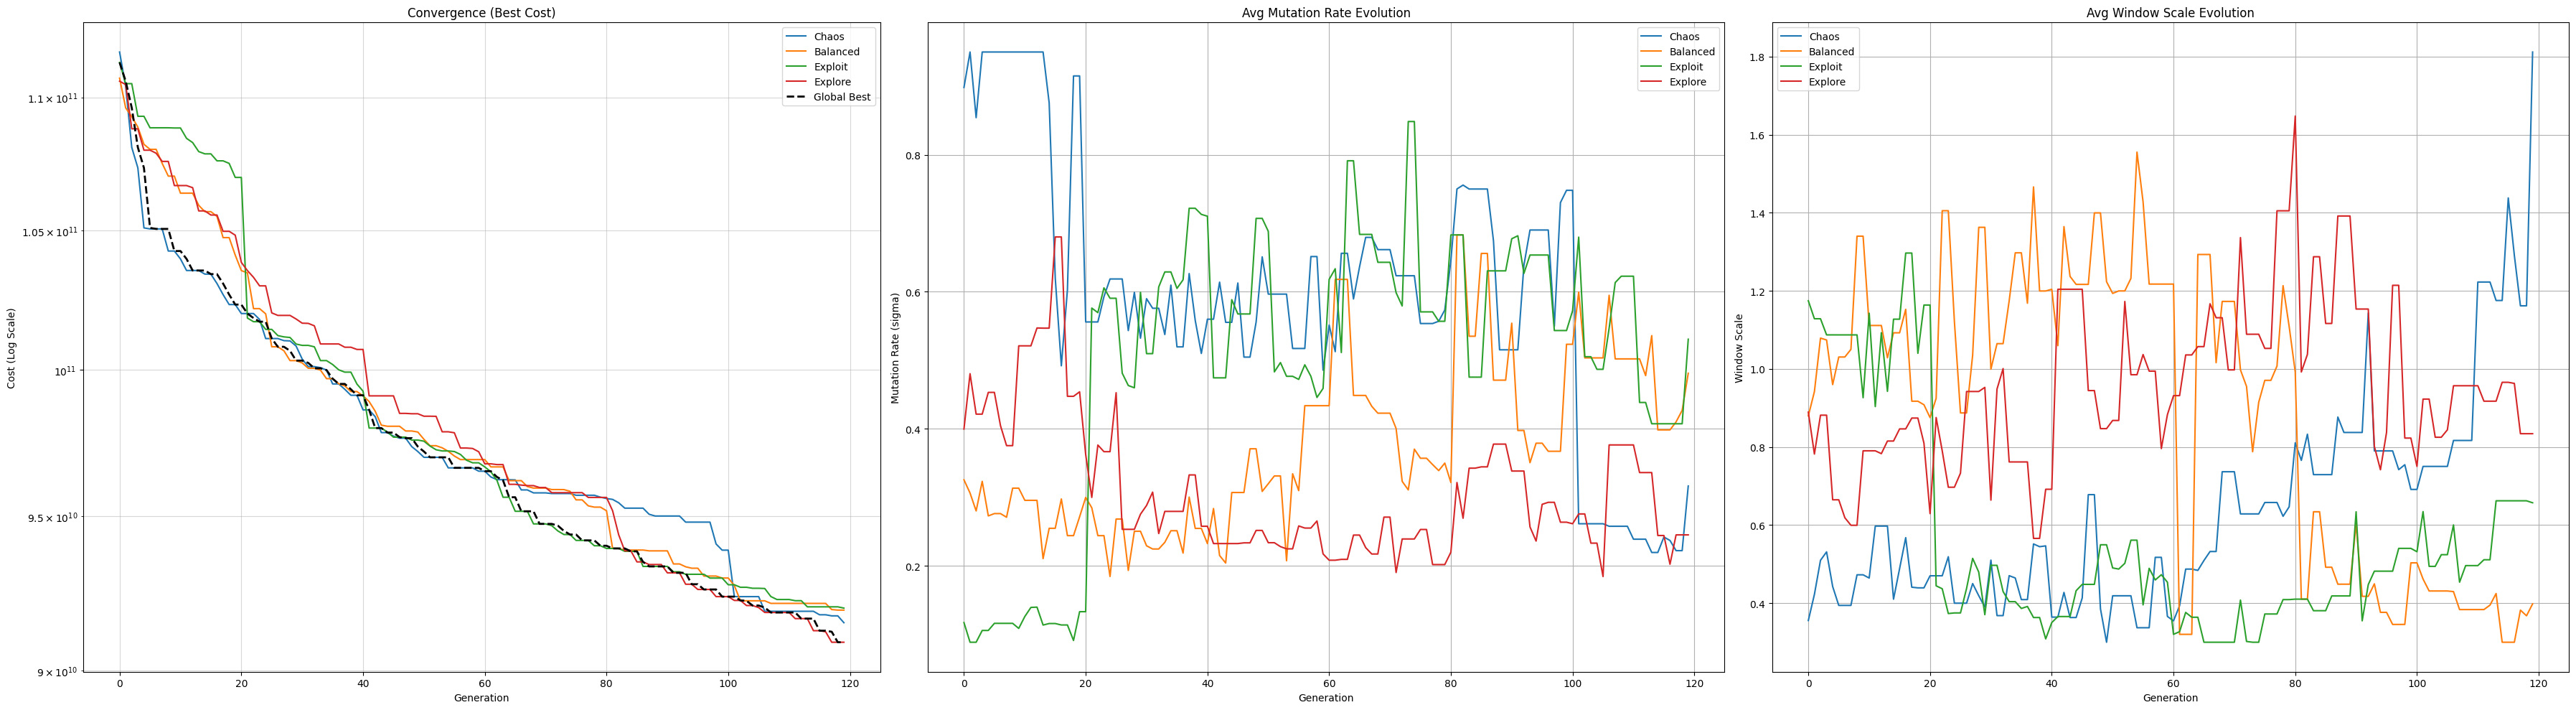

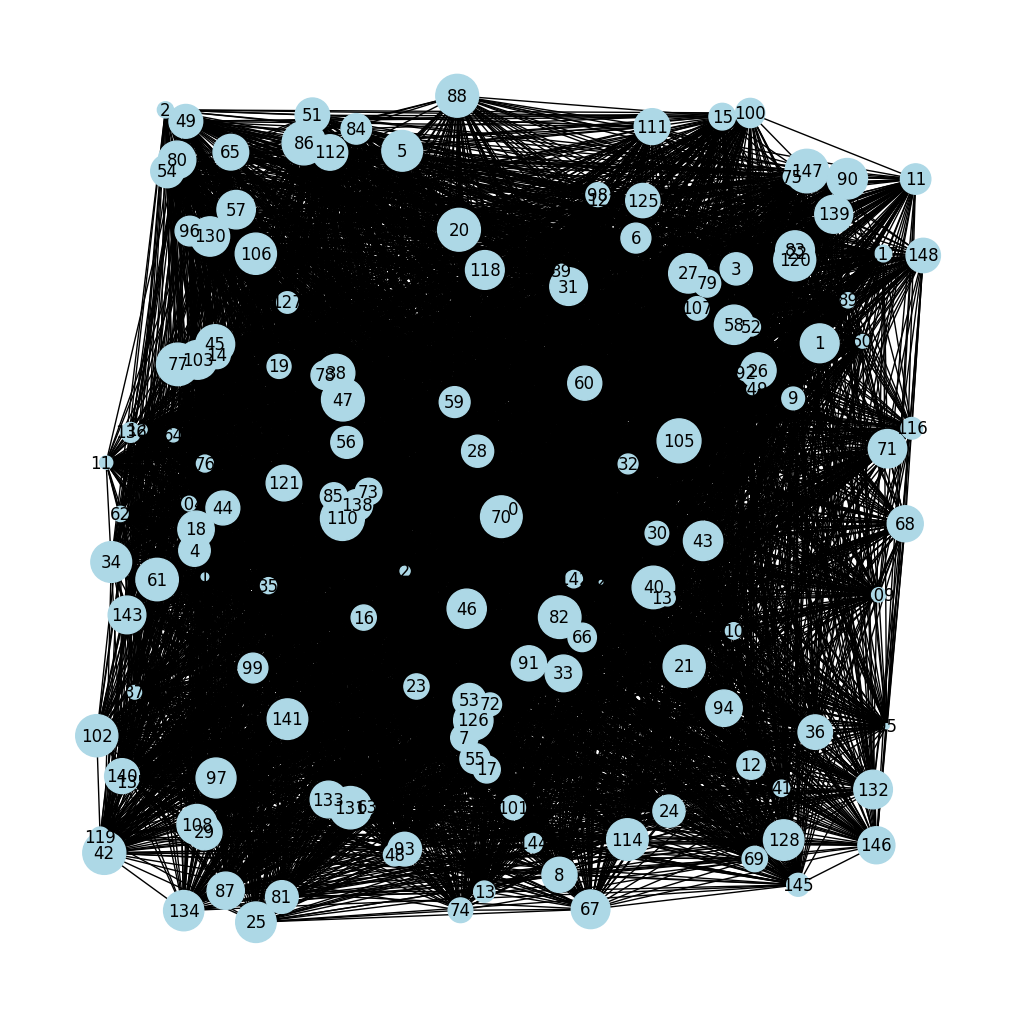

In [25]:
print(f"\nFinal Solution Cost: {best_ind.cost:.2e}")

fig, axes = plt.subplots(1, 3, figsize=(36, 10))

# 1. Convergence Plot
for role, data in history['islands'].items():
    axes[0].plot(history['gen'], data['best_cost'], label=role)
axes[0].plot(history['gen'], history['global_best'], 'k--', linewidth=2, label='Global Best')
axes[0].set_title('Convergence (Best Cost)')
axes[0].set_xlabel('Generation')
axes[0].set_ylabel('Cost (Log Scale)')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(True, which="both", ls="-", alpha=0.5)

# 2. Adaptive Mutation Rate Evolution
for role, data in history['islands'].items():
    axes[1].plot(history['gen'], data['avg_mut_rate'], label=role)
axes[1].set_title('Avg Mutation Rate Evolution')
axes[1].set_xlabel('Generation')
axes[1].set_ylabel('Mutation Rate (sigma)')
axes[1].legend()
axes[1].grid(True)

# 3. Adaptive Window Scale Evolution
for role, data in history['islands'].items():
    axes[2].plot(history['gen'], data['avg_win_scale'], label=role)
axes[2].set_title('Avg Window Scale Evolution')
axes[2].set_xlabel('Generation')
axes[2].set_ylabel('Window Scale')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

# Show Graph
problem.plot()

## 6. Comparison with Baseline
We compare our result against the provided baseline algorithm (Dijkstra-based simple routing).

In [26]:
baseline_cost = problem.baseline()
print(f"Baseline Cost: {baseline_cost:.2e}")
print(f"My Solution Cost: {best_ind.cost:.2e}")

if best_ind.cost < baseline_cost:
    factor = baseline_cost / best_ind.cost
    print(f"Improvement Factor: {factor:.2f}x better")
else:
    print("No improvement.")

Baseline Cost: 2.33e+14
My Solution Cost: 9.09e+10
Improvement Factor: 2564.24x better
